# Task 1: Exploring and Visualizing the Iris Dataset

## Introduction
This notebook is part of my Data Science & Analytics Internship at DevelopersHub Corporation.
The objective of this task is to understand how to read, summarize, and visualize a dataset
using Python libraries including pandas, matplotlib, and seaborn.

## Problem Statement
I am working with the Iris dataset.It contains measurements of 150 flowers 
across 3 species: Setosa, Versicolor, and Virginica.Our goal is to explore the
data, understand its structure, and visualize patterns within it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Iris dataset from CSV file into a pandas DataFrame
df = pd.read_csv("Iris Dataset.csv")

## Dataset Description
The Iris dataset contains 150 rows and 5 columns:
- sepal_length: Length of the sepal in cm
- sepal_width: Width of the sepal in cm
- petal_length: Length of the petal in cm
- petal_width: Width of the petal in cm
- species: The flower species (Setosa, Versicolor, Virginica)

There are 50 flowers per species, making this a balanced dataset.

In [3]:
# Display the first 5 rows to get a quick preview of the data
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Printing the dimensions of the dataset (rows, columns)
print(df.shape)
# Printing the names of all columns in the dataset
print(df.columns)

(150, 5)
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


In [5]:
# Generating statistical summary for all numerical columns
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Data Cleaning & Preparation
Before analysis, we check if the dataset has any missing values or duplicates.

In [10]:
# Checking how many missing values exist in each column
# A result of 0 for all columns means the data is clean
print(df.isnull().sum())

# Checking if any rows are exact duplicates of another row
print("Duplicate rows:", df.duplicated().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Duplicate rows: 1


In [11]:
# Removing the duplicate row from the dataset
# keep='first' means we keep the original and delete the copy
df = df.drop_duplicates(keep='first')

# Confirming the duplicate has been removed
print("Duplicate rows after cleaning:", df.duplicated().sum())

# Checking the new shape of the dataset after removing the duplicate
print("New shape:", df.shape)

Duplicate rows after cleaning: 0
New shape: (149, 5)


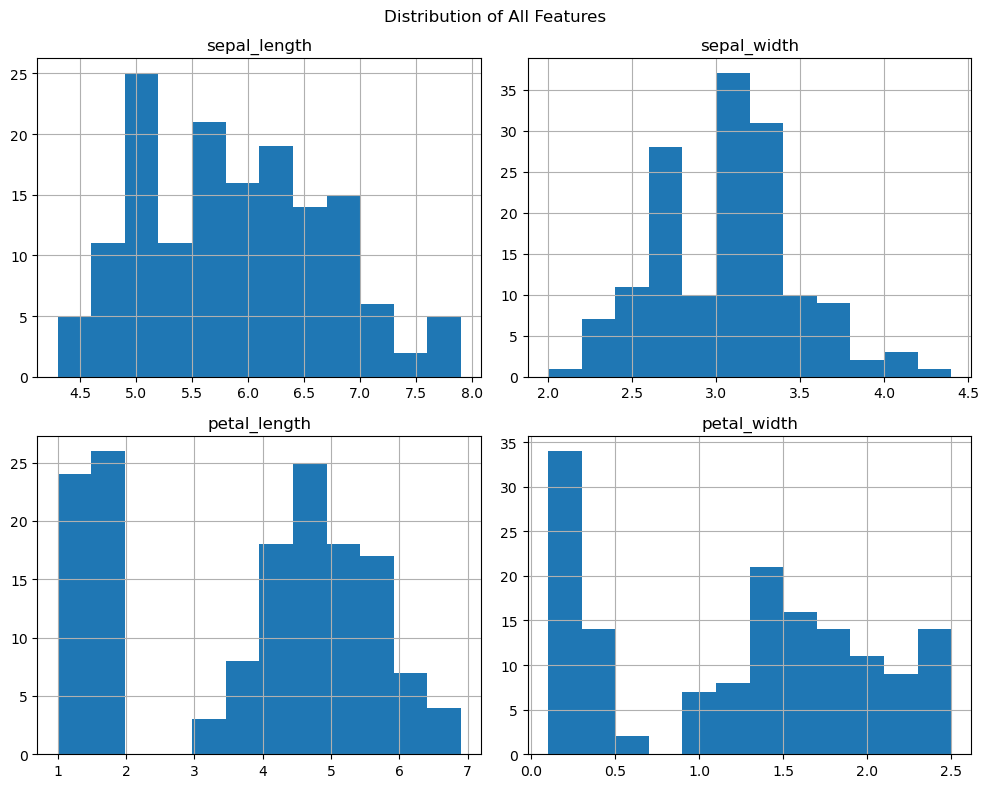

In [6]:
# Drawing histograms for all numerical columns at once
# bins=12 chosen using the square root rule (√150 ≈ 12)
# figsize sets the width and height of the entire figure in inches

df.hist(bins = 12, figsize = (10,8))

# Adding a main title above all the histograms
plt.suptitle("Distribution of All Features")

# Automatically adjusting spacing so charts do not overlap
plt.tight_layout()

# Displaying the figure on screen
plt.show()

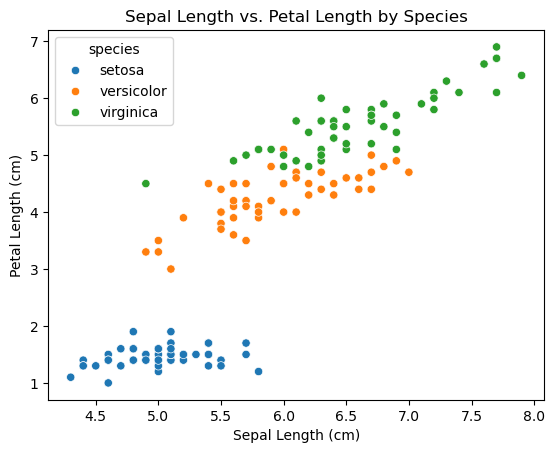

In [7]:
# Drawing a scatter plot to analyze the relationship between sepal and petal length
# hue='species' colors each dot by species so we can see group separation

sns.scatterplot(data = df, x = 'sepal_length', y = 'petal_length', hue = 'species')

# Adding title and axis labels to make the chart readable
plt.title('Sepal Length vs. Petal Length by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')

# Displaying the chart
plt.show()

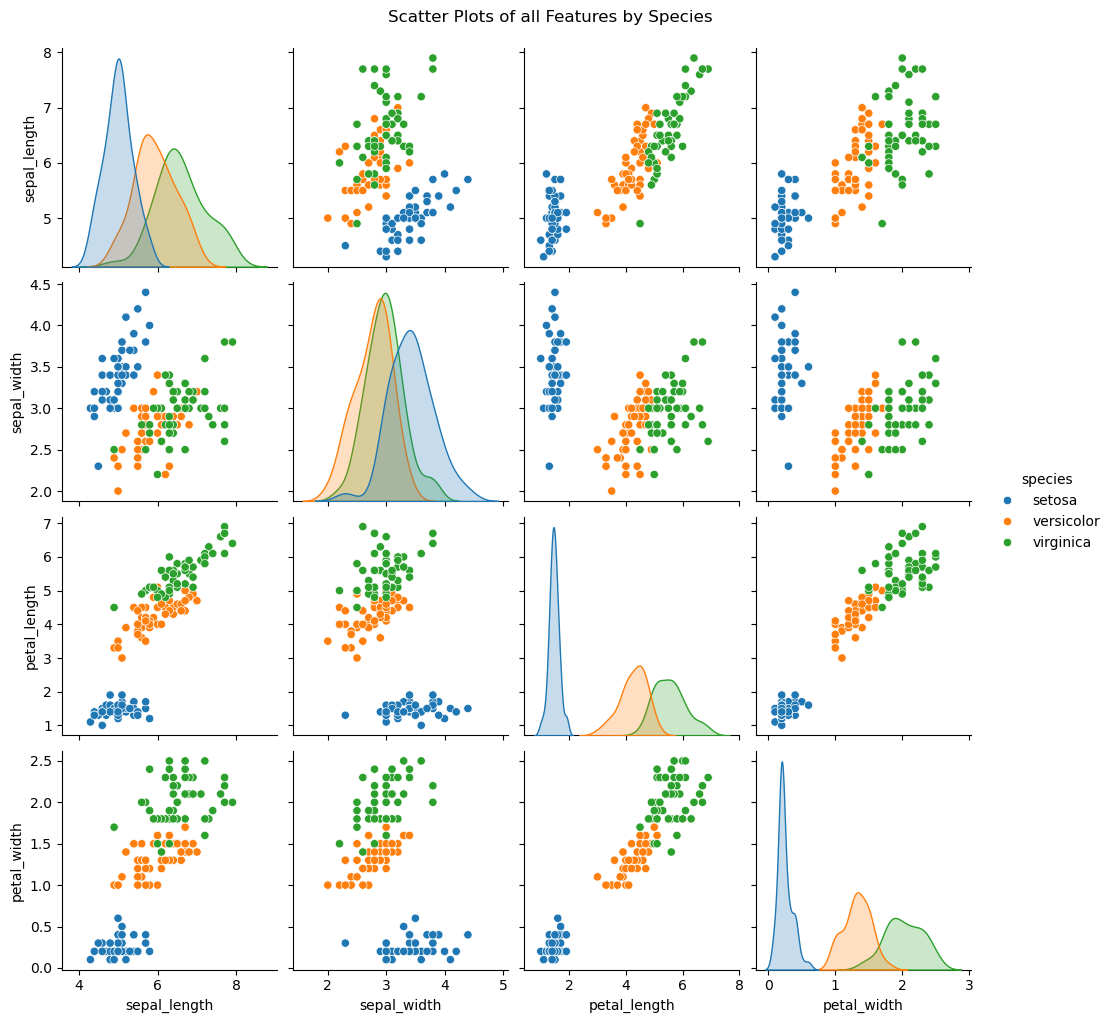

In [8]:
# Drawing scatter plots for every combination of columns at once
# hue='species' colors dots by species across all plots
# Diagonal cells show density curves (KDE) instead of scatter plots

sns.pairplot(df, hue = 'species')

# Adding a main title slightly above the grid so it does not overlap
# y=1.02 pushes the title 2% above the top of the figure
plt.suptitle("Scatter Plots of all Features by Species", y = 1.02)

# Displaying the entire grid
plt.show()

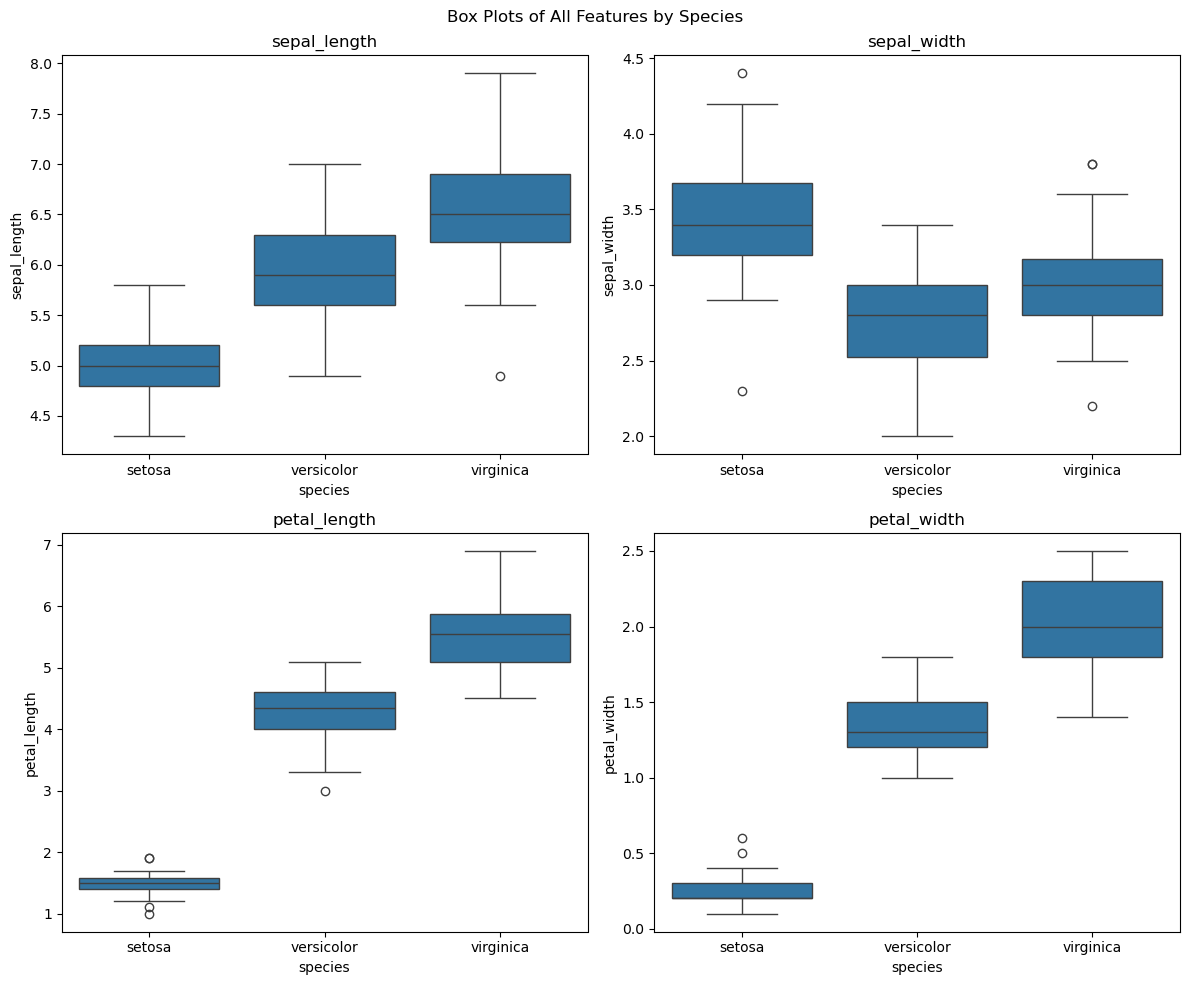

In [9]:
# Creating a 2x2 grid of chart spaces to hold 4 box plots
# figsize sets the overall size of the figure

fig, axes = plt.subplots(2, 2, figsize = (12, 10))

# Adding a main title for the entire figure
plt.suptitle("Box Plots of All Features by Species")

# List of all numerical columns we want to plot
cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Looping through each column to draw one box plot per column
for i, col in enumerate(cols):
    # Calculating which row and column in the grid this chart belongs to
    # i // 2 gives the row (0 or 1), i % 2 gives the column (0 or 1)
    
    ax = axes[i//2, i%2]

    # Drawing the box plot for this column in the correct grid space
    # ax=ax tells seaborn exactly which space to draw in
    sns.boxplot(data = df, x = 'species', y = col, ax = ax)

    # Setting the title of this individual chart to the column name
    ax.set_title(col)
    
# Adjusting spacing between charts so they do not overlap
plt.tight_layout()

# Displaying the entire figure
plt.show()

## Conclusion & Key Insights

Statistical analysis revealed that petal measurements vary far more than sepal measurements across species. Petal length showed a
standard deviation of 1.77 compared to sepal width's 0.44. This suggested early on that petals would be the stronger identifier of species.

Visualizations confirmed this consistently:

1. Histograms showed smooth distributions for sepal features but two distinct clusters with a clear gap for petal features, hinting at natural species groupings in the data.

2. The scatter plot revealed three clearly separated species clusters and a strong positive correlation between sepal length and petal length, as one increases, the other tends to rise as well.

3. The pair plot expanded this view across every feature combination, with density curves confirming that Setosa is completely detached from the other two species in petal measurements.

4. Box plots confirmed that Setosa has the shortest and most consistent petals with very little spread. Virginica has the longest petals but the most variation. Versicolor sits in between with one outlier detected near 3.0 cm in petal length.

Overall, Setosa is completely distinct from Versicolor and Virginica across all petal measurements. These findings suggest that a machine learning model trained on petal features would achieve high classification accuracy.